In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import pyneb as pn

import numpy as np
import matplotlib.pyplot as plt
import astropy
from astropy.io import fits
from scipy.interpolate import Akima1DInterpolator
from scipy import optimize as opt
import sys
import emcee
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from astropy.table import Table
import matplotlib

import numpy as np
from astropy.io import fits
import time
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from scipy import signal
import matplotlib.pyplot as plt
import warnings

In [23]:
final_table = pd.read_csv('Merge_Masses.txt', sep=' ')
final_table

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,491,492,493,494,495,496,497,498,499,Survey
0,128,8.865297,8.825484,8.841904,8.834379,8.830118,8.799893,8.807796,8.820146,8.847009,...,8.837957,8.824711,8.840246,8.844164,8.813274,8.831680,8.820089,8.816011,8.818094,CEERS
1,411,7.360127,7.319807,7.461480,7.495797,7.616152,7.452359,7.429566,7.474265,7.641241,...,7.582927,7.571934,7.377228,7.588876,7.491953,7.511542,7.476974,7.551864,7.489444,CEERS
2,553,9.419298,9.336021,9.289716,9.375046,9.458132,9.264803,9.384586,9.348078,9.367330,...,9.316295,9.363650,9.345962,9.299037,9.294169,9.417537,9.400234,9.382177,9.296415,CEERS
3,710,10.748258,10.733195,10.746497,10.751131,10.729539,10.790181,10.794160,10.749090,10.720123,...,10.751382,10.739677,10.781512,10.780438,10.768779,10.739116,10.806103,10.755827,10.714874,CEERS
4,997,8.528187,8.559403,8.622791,8.621200,8.364078,8.618005,8.560083,8.636252,8.424564,...,8.599149,8.582338,8.458916,8.513491,8.628582,8.679909,8.617180,8.547936,8.539983,CEERS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846,102732,8.118563,8.156534,8.130804,8.071963,8.147022,8.103141,8.057444,8.150097,8.382663,...,8.083121,8.049237,8.166922,8.106849,8.088189,8.147697,8.092877,8.145632,8.161658,UDS
847,103564,7.801712,7.864932,7.744531,7.809701,7.885526,7.843717,7.749731,7.827285,7.818227,...,7.752795,7.835280,7.822094,7.812528,7.814893,7.918716,7.979194,7.794816,7.880900,UDS
848,156579,9.718904,10.207075,10.387735,9.922763,10.366404,10.049555,10.103119,10.104015,10.020951,...,10.463742,10.454117,10.353230,10.403357,10.252300,10.587232,10.345571,10.639135,10.497529,UDS
849,157419,8.498218,9.718096,9.447481,9.488349,8.999075,9.423484,8.168330,8.003041,9.021352,...,8.910984,9.141551,9.446024,9.508587,7.918525,9.599624,7.972477,8.407784,7.742017,UDS


In [24]:
data = Table.read('Lipika_Sources_Matched.fits')
data

MSA_ID,g395mfile,RA,DEC,z_spec,CEERS_idx,CEERS_sep,UDS_idx,UDS_sep,Survey,CEERS_ID,UDS_ID,CEERS_Duplicated_ID,UDS_Duplicated_ID
int64,bytes64,float64,float64,float64,int64,float64,int64,float64,bytes5,int32,int32,bool,bool
314,jw04233005002_CEERS-FULL-V2_F290LP_G395M_s00314_x1d.fits,215.04721947997,52.87354503439,1.0829999446868896,31510,0.08143998043065417,119036,475912.27250012924,CEERS,31572,119577,False,True
482,jw04233005002_CEERS-FULL-V2_F290LP_G395M_s00482_x1d.fits,215.05570032835,52.88195828589,2.4791998863220215,31424,0.005087324643786691,119036,475881.6362728698,CEERS,31486,119577,False,True
761,jw04233005002_CEERS-FULL-V2_F290LP_G395M_s00761_x1d.fits,215.0482805167,52.87997494891,3.4749999046325684,31324,0.011908691921862053,119036,475889.0849400417,CEERS,31385,119577,False,True
920,jw04233005002_CEERS-FULL-V2_F290LP_G395M_s00920_x1d.fits,215.05234431203,52.88426776604,3.6214001178741455,31278,0.011890282612682454,119036,475873.4642278657,CEERS,31339,119577,False,True
921,jw04233005002_CEERS-FULL-V2_F290LP_G395M_s00921_x1d.fits,215.04980383673,52.88251996754,4.617599964141846,31277,0.025434767231240087,119036,475879.86114541144,CEERS,31338,119577,False,True
1363,jw04233005001_CEERS-FULL-V2_F290LP_G395M_s01363_x1d.fits,215.13729090229,52.94715585374,1.1676000356674194,31126,0.025786493938053368,119036,475643.3843877904,CEERS,31187,119577,False,True
1386,jw04233005002_CEERS-FULL-V2_F290LP_G395M_s01386_x1d.fits,215.05447745934,52.88792545519,4.112599849700928,31184,0.006629155736246148,119036,475860.20973758225,CEERS,31245,119577,False,True
1458,jw04233005001_CEERS-FULL-V2_F290LP_G395M_s01458_x1d.fits,215.14469496214,52.95265107673,1.690999984741211,31078,0.008149162048547931,119036,475623.2640904758,CEERS,31139,119577,False,True
1519,jw04233005002_CEERS-FULL-V2_F290LP_G395M_s01519_x1d.fits,215.0315623156,52.87206831924,3.2648000717163086,31153,0.002138691045727901,119036,475918.23197477753,CEERS,31214,119577,False,True


In [25]:

mass_table = pd.read_csv('Merge_Masses.txt', sep=' ')
close_matches = Table.read('Lipika_Sources_Matched.fits')

# Convert the Astropy Table to a pandas DataFrame
close_matches_df = close_matches.to_pandas()

# Rename the 0th column in mass_table for clarity
mass_table.rename(columns={mass_table.columns[0]: 'ID'}, inplace=True)

# Determine the correct ID column from close_matches to use based on the 'Survey' value
# Creating a column to store the match ID from the appropriate column based on the survey
mass_table['Match_ID'] = mass_table.apply(
    lambda row: row['ID'] if row['Survey'] == 'CEERS' else (row['ID'] if row['Survey'] == 'UDS' else None), axis=1)

# Merge based on the 'Match_ID' which contains the ID from 'ID' column
# We use a conditional merge depending on the survey type, so two merges might be necessary
ceers_merged = pd.merge(mass_table[mass_table['Survey'] == 'CEERS'], close_matches_df, left_on='Match_ID', right_on='CEERS_ID', how='inner')
uds_merged = pd.merge(mass_table[mass_table['Survey'] == 'UDS'], close_matches_df, left_on='Match_ID', right_on='UDS_ID', how='inner')

# Concatenate both dataframes to form the final merged dataframe
final_merged = pd.concat([ceers_merged, uds_merged])

# Convert byte strings in the 'g395mfile' column to regular strings
final_merged['g395mfile'] = final_merged['g395mfile'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

# Display the updated 'g395mfile' column to verify the changes
print(final_merged['g395mfile'])


0      jw04233006001_CEERS-FULL-V2_F290LP_G395M_s7614...
1      jw04233006001_CEERS-FULL-V2_F290LP_G395M_s7558...
2      jw04233006002_CEERS-FULL-V2_F290LP_G395M_s7556...
3      jw04233006001_CEERS-FULL-V2_F290LP_G395M_s7500...
4      jw04233006001_CEERS-FULL-V2_F290LP_G395M_s7439...
                             ...                        
258    jw04233001003_PRIMER-UDS-FULL-V4_F290LP_G395M_...
259    jw04233001003_PRIMER-UDS-FULL-V4_F290LP_G395M_...
260    jw04233001002_PRIMER-UDS-FULL-V4_F290LP_G395M_...
261    jw04233001002_PRIMER-UDS-FULL-V4_F290LP_G395M_...
262    jw04233001003_PRIMER-UDS-FULL-V4_F290LP_G395M_...
Name: g395mfile, Length: 851, dtype: object


In [26]:
final_merged['median_mass'] = final_merged.iloc[:, 0:500].median(axis=1)
print(final_merged[['g395mfile', 'median_mass']])


                                             g395mfile  median_mass
0    jw04233006001_CEERS-FULL-V2_F290LP_G395M_s7614...     8.825945
1    jw04233006001_CEERS-FULL-V2_F290LP_G395M_s7558...     7.493044
2    jw04233006002_CEERS-FULL-V2_F290LP_G395M_s7556...     9.321102
3    jw04233006001_CEERS-FULL-V2_F290LP_G395M_s7500...    10.755848
4    jw04233006001_CEERS-FULL-V2_F290LP_G395M_s7439...     8.573090
..                                                 ...          ...
258  jw04233001003_PRIMER-UDS-FULL-V4_F290LP_G395M_...     8.118535
259  jw04233001003_PRIMER-UDS-FULL-V4_F290LP_G395M_...     7.835063
260  jw04233001002_PRIMER-UDS-FULL-V4_F290LP_G395M_...    10.269636
261  jw04233001002_PRIMER-UDS-FULL-V4_F290LP_G395M_...     9.117216
262  jw04233001003_PRIMER-UDS-FULL-V4_F290LP_G395M_...     7.577475

[851 rows x 2 columns]


In [27]:
import pandas as pd
import numpy as np
from astropy.table import Table

# Load the RUBIES_and_CEERS_table from a FITS file
RUBIES_and_CEERS_table = Table.read('MASTER_RUBIES_AND_CEERS_TABLE.fits')

# Convert the Astropy Table to a pandas DataFrame
RUBIES_and_CEERS_df = RUBIES_and_CEERS_table.to_pandas()

# Convert byte strings in the 'filename' column to regular strings, if necessary
RUBIES_and_CEERS_df['filename'] = RUBIES_and_CEERS_df['filename'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

# Create a dictionary from final_merged to map 'g395mfile' to 'median_mass'
file_mass_mapping = dict(zip(final_merged['g395mfile'], final_merged['median_mass']))

# Add a new column for median_mass in RUBIES_and_CEERS_df initialized to NaN
RUBIES_and_CEERS_df['median_mass'] = np.nan

# Iterate over each filename in RUBIES_and_CEERS_df to check for matches and update median_mass
for idx, filename in enumerate(RUBIES_and_CEERS_df['filename']):
    # Check if the filename exists in the final_merged 'g395mfile'
    if filename in file_mass_mapping:
        # If found, update the 'median_mass' with the corresponding value
        RUBIES_and_CEERS_df.at[idx, 'median_mass'] = file_mass_mapping[filename]

# Convert the updated pandas DataFrame back to an Astropy Table
updated_table = Table.from_pandas(RUBIES_and_CEERS_df)
updated_table.write('MASS_RUBIES_AND_CEERS_TABLE.fits', overwrite=True)
updated_table


filename,rest_frame_wavelength,flux,redshift,flux_error,flags,ra,dec,wavelength,flux_lambda,flux_error_lambda,catalog,obs_wavelength_in_ang,rest_frame_wavelength_in_ang,flux_lambda_cleaned,flux_error_lambda_cleaned,rest_frame_wavelength_cleaned,obs_wavelength_cleaned,flux_intrinsic,flux_error_corrected,dust_corrected,ratios,which_ratio,new_rubies_redshifts,new_restframe_in_ang,F277W,ratio_84th,dust_correction_flag,median_mass
str72,object,object,float64,object,bool,float64,float64,object,object,object,bytes6,object,object,object,object,object,object,object,object,bytes3,float64,bytes6,float64,object,float64,float64,bool,float64
hlsp_ceers_jwst_nirspec_nirspec10-000023_comb-mgrat_v0.7_x1d-masked.fits,[0.13646702 0.13655724 0.13664746 ... 0.73018126 0.73043525 0.73068925],[ 0. 0. nan ... nan nan nan],6.0512736702065855,[nan nan nan ... nan nan nan],True,214.876469,52.839412,[0.96226629 0.96290248 0.96353867 ... 5.14870789 5.15049887 5.15228984],[ 0. 0. nan ... nan nan nan],[nan nan nan ... nan nan nan],CEERS,[ 9622.66289288 9629.02477967 9635.38667652 ... 51487.07892761\n 51504.98867357 51522.8983846 ],[1364.67017775 1365.57241004 1366.47464376 ... 7301.8125995 7304.35253012\n 7306.8924558 ],[ 0. 0. nan ... nan nan nan],[nan nan nan ... nan nan nan],[1364.67017775 1365.57241004 1366.47464376 ... 7301.8125995 7304.35253012\n 7306.8924558 ],[ 9622.66289288 9629.02477967 9635.38667652 ... 51487.07892761\n 51504.98867357 51522.8983846 ],[ 0. 0. nan ... nan nan nan],[nan nan nan ... nan nan nan],Yes,4.013046941902093,Halpha,6.0512736702065855,[1364.67017775 1365.57241004 1366.47464376 ... 7301.8125995 7304.35253012\n 7306.8924558 ],27.361566445612876,4.013046941902093,True,--
hlsp_ceers_jwst_nirspec_nirspec10-000024_comb-mgrat_v0.7_x1d-masked.fits,[0.12564756 0.12572675 0.12580594 ... 0.65776864 0.65799001 0.65821138],[nan nan nan ... nan nan nan],7.0308386300914645,[nan nan nan ... nan nan nan],True,214.839316,52.882565,[1.00905527 1.00969124 1.01032721 ... 5.28243381 5.2842116 5.28598937],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],CEERS,[10090.55268918 10096.91241293 10103.27210842 ... 52824.33807727\n 52842.11595644 52859.89370483],[1256.47558791 1257.26750069 1258.05940995 ... 6577.68640492 6579.90010638\n 6582.11379155],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[1256.47558791 1257.26750069 1258.05940995 ... 6577.68640492 6579.90010638\n 6582.11379155],[10090.55268918 10096.91241293 10103.27210842 ... 52824.33807727\n 52842.11595644 52859.89370483],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],Yes,1.8528751380770774,Hgamma,7.0308386300914645,[1256.47558791 1257.26750069 1258.05940995 ... 6577.68640492 6579.90010638\n 6582.11379155],28.182391588608642,1.8528751380770774,True,--
hlsp_ceers_jwst_nirspec_nirspec10-000515_comb-mgrat_v0.7_x1d-masked.fits,[0.14382026 0.1439111 0.14400194 ... 0.7543949 0.75464883 0.75490275],[nan nan nan ... nan nan nan],6.002401236437165,[nan nan nan ... nan nan nan],True,214.836197,52.882693,[1.00708719 1.00772326 1.00835934 ... 5.2825758 5.28435387 5.28613193],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],CEERS,[10070.87186006 10077.23263077 10083.59337318 ... 52825.75799174\n 52843.53869368 52861.31926507],[1438.20262793 1439.11099786 1440.01936375 ... 7543.94902664 7546.48825587\n 7549.02746647],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[1438.20262793 1439.11099786 1440.01936375 ... 7543.94902664 7546.48825587\n 7549.02746647],[10070.87186006 10077.23263077 10083.59337318 ... 52825.75799174\n 52843.53869368 52861.31926507],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],Yes,2.726175284619157,Halpha,6.002401236437165,[1438.20262793 1439.11099786 1440.01936375 ... 7543.94902664 7546.48825587\n 7549.02746647],25.26174308252525,2.726175284619157,True,--
hlsp_ceers_jwst_nirspec_nirspec10-000618_comb-mgrat_v0.7_x1d-masked.fits,[0.15349724 0.15359826 0.15369928 ... 0.84247839 0.84276021 0.84304202],[nan nan nan ...

In [28]:
mass_table = Table.read('MASS_RUBIES_AND_CEERS_TABLE.fits')

mask = ((mass_table['catalog']=='RUBIES') & (mass_table['flags']== True))
%matplotlib widget
matplotlib.style.use('paper')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.linewidth'] = 1.5


plt.figure()
plt.scatter(mass_table['new_rubies_redshifts'][mask], mass_table['median_mass'][mask], color = 'darkseagreen',s = 28,label=')
plt.xlabel('$z$')
plt.ylabel(r'Mass (in units of $M_{\odot}$)')
plt.title('Redshift vs. Mass')
plt.subplots_adjust(bottom=0.15) 
plt.savefig('mass_vs_redshift.pdf')

plt.show()

SyntaxError: unterminated string literal (detected at line 12) (2323931492.py, line 12)

In [ ]:
data = pd.read_csv('../Capstone Project/mass_table.txt', sep=' ')
data['SOURCE_NAME_x']
#data['median_mass']

In [29]:
import pandas as pd

# Load your data from a text file
data = pd.read_csv('../Capstone Project/mass_table.txt', sep=' ')

# Check if the column is in byte string format and decode it
if isinstance(data['SOURCE_NAME_x'].iloc[0], bytes):
    data['SOURCE_NAME_x'] = data['SOURCE_NAME_x'].apply(lambda x: x.decode('utf-8'))
else:
    # If the column contains strings with a byte-like appearance, e.g., "b'string'", strip the unwanted characters
    data['SOURCE_NAME_x'] = data['SOURCE_NAME_x'].str.replace("^b'|'$", '', regex=True)

# Print the cleaned column to verify
print(data['SOURCE_NAME_x'].head())


0    hlsp_ceers_jwst_nirspec_nirspec4-000407_comb-m...
1    hlsp_ceers_jwst_nirspec_nirspec4-000397_comb-m...
2    hlsp_ceers_jwst_nirspec_nirspec4-001465_comb-m...
3    hlsp_ceers_jwst_nirspec_nirspec4-011699_comb-m...
4    hlsp_ceers_jwst_nirspec_nirspec4-000496_comb-m...
Name: SOURCE_NAME_x, dtype: object


In [31]:


from astropy.table import Table
import pandas as pd

# Load the FITS file into an Astropy Table
updated_table = Table.read('MASS_RUBIES_AND_CEERS_TABLE.fits')

# Convert it to a DataFrame for easier manipulation
updated_df = updated_table.to_pandas()
for column in updated_df.columns:
    if updated_df[column].dtype == 'object':  # Checking for object type which might be strings
        updated_df[column] = updated_df[column].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)


In [32]:
# Create a mapping from filenames to median_mass from the 'data' DataFrame
filename_to_mass = dict(zip(data['SOURCE_NAME_x'], data['median_mass']))

# Iterate through the DataFrame to update the 'median_mass' based on matching filenames
for idx, row in updated_df.iterrows():
    # Check if the filename in updated_df is in the dictionary
    if row['filename'] in filename_to_mass:
        # Update the median_mass for matches
        updated_df.at[idx, 'median_mass'] = filename_to_mass[row['filename']]

# Convert updated_df back to an Astropy Table if needed to save back to FITS
updated_table = Table.from_pandas(updated_df)

# Save the updated table back to a FITS file
updated_table.write('MASS_RUBIES_AND_CEERS_TABLE.fits', overwrite=True)

In [33]:
updated_table

filename,rest_frame_wavelength,flux,redshift,flux_error,flags,ra,dec,wavelength,flux_lambda,flux_error_lambda,catalog,obs_wavelength_in_ang,rest_frame_wavelength_in_ang,flux_lambda_cleaned,flux_error_lambda_cleaned,rest_frame_wavelength_cleaned,obs_wavelength_cleaned,flux_intrinsic,flux_error_corrected,dust_corrected,ratios,which_ratio,new_rubies_redshifts,new_restframe_in_ang,F277W,ratio_84th,dust_correction_flag,median_mass
str72,object,object,float64,object,bool,float64,float64,object,object,object,str6,object,object,object,object,object,object,object,object,str3,float64,str6,float64,object,float64,float64,bool,float64
hlsp_ceers_jwst_nirspec_nirspec10-000023_comb-mgrat_v0.7_x1d-masked.fits,[0.13646702 0.13655724 0.13664746 ... 0.73018126 0.73043525 0.73068925],[ 0. 0. nan ... nan nan nan],6.0512736702065855,[nan nan nan ... nan nan nan],True,214.876469,52.839412,[0.96226629 0.96290248 0.96353867 ... 5.14870789 5.15049887 5.15228984],[ 0. 0. nan ... nan nan nan],[nan nan nan ... nan nan nan],CEERS,[ 9622.66289288 9629.02477967 9635.38667652 ... 51487.07892761\n 51504.98867357 51522.8983846 ],[1364.67017775 1365.57241004 1366.47464376 ... 7301.8125995 7304.35253012\n 7306.8924558 ],[ 0. 0. nan ... nan nan nan],[nan nan nan ... nan nan nan],[1364.67017775 1365.57241004 1366.47464376 ... 7301.8125995 7304.35253012\n 7306.8924558 ],[ 9622.66289288 9629.02477967 9635.38667652 ... 51487.07892761\n 51504.98867357 51522.8983846 ],[ 0. 0. nan ... nan nan nan],[nan nan nan ... nan nan nan],Yes,4.013046941902093,Halpha,6.0512736702065855,[1364.67017775 1365.57241004 1366.47464376 ... 7301.8125995 7304.35253012\n 7306.8924558 ],27.361566445612876,4.013046941902093,True,8.023972313734895
hlsp_ceers_jwst_nirspec_nirspec10-000024_comb-mgrat_v0.7_x1d-masked.fits,[0.12564756 0.12572675 0.12580594 ... 0.65776864 0.65799001 0.65821138],[nan nan nan ... nan nan nan],7.0308386300914645,[nan nan nan ... nan nan nan],True,214.839316,52.882565,[1.00905527 1.00969124 1.01032721 ... 5.28243381 5.2842116 5.28598937],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],CEERS,[10090.55268918 10096.91241293 10103.27210842 ... 52824.33807727\n 52842.11595644 52859.89370483],[1256.47558791 1257.26750069 1258.05940995 ... 6577.68640492 6579.90010638\n 6582.11379155],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[1256.47558791 1257.26750069 1258.05940995 ... 6577.68640492 6579.90010638\n 6582.11379155],[10090.55268918 10096.91241293 10103.27210842 ... 52824.33807727\n 52842.11595644 52859.89370483],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],Yes,1.8528751380770774,Hgamma,7.0308386300914645,[1256.47558791 1257.26750069 1258.05940995 ... 6577.68640492 6579.90010638\n 6582.11379155],28.182391588608642,1.8528751380770774,True,7.771703742546965
hlsp_ceers_jwst_nirspec_nirspec10-000515_comb-mgrat_v0.7_x1d-masked.fits,[0.14382026 0.1439111 0.14400194 ... 0.7543949 0.75464883 0.75490275],[nan nan nan ... nan nan nan],6.002401236437165,[nan nan nan ... nan nan nan],True,214.836197,52.882693,[1.00708719 1.00772326 1.00835934 ... 5.2825758 5.28435387 5.28613193],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],CEERS,[10070.87186006 10077.23263077 10083.59337318 ... 52825.75799174\n 52843.53869368 52861.31926507],[1438.20262793 1439.11099786 1440.01936375 ... 7543.94902664 7546.48825587\n 7549.02746647],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[1438.20262793 1439.11099786 1440.01936375 ... 7543.94902664 7546.48825587\n 7549.02746647],[10070.87186006 10077.23263077 10083.59337318 ... 52825.75799174\n 52843.53869368 52861.31926507],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],Yes,2.726175284619157,Halpha,6.002401236437165,[1438.20262793 1439.11099786 1440.01936375 ... 7543.94902664 7546.48825587\n 7549.02746647],25.26174308252525,2.726175284619157,True,7.517943267476057
hlsp_ceers_jwst_nirspec_nirspec10-000618_comb-mgrat_v0.7_x1d-masked.fits,[0.15349724 0.15359826 0.15369928 ... 0.84247839 

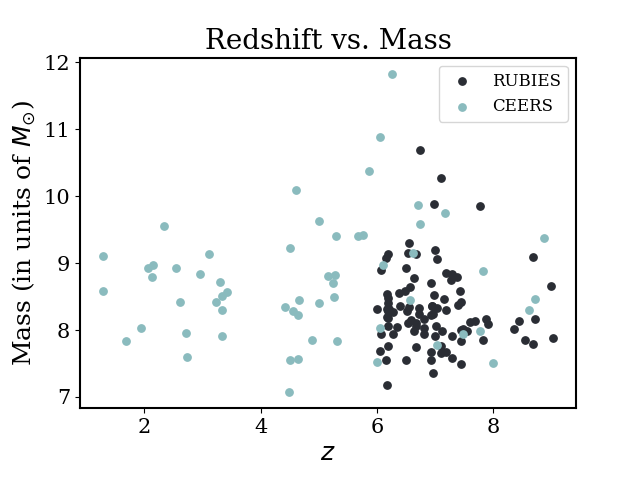

In [36]:
 import matplotlib.pyplot as plt
from astropy.table import Table

%matplotlib widget
# Read your FITS table
mass_table = Table.read('MASS_RUBIES_AND_CEERS_TABLE.fits')

# Apply the mask for flagged entries
mask = mass_table['flags']

# Setting the style, but overriding specific elements later
plt.style.use('paper')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.linewidth'] = 1.5

# Prepare the figure
plt.figure()

# Define catalog colors
catalog_colors = {'RUBIES': '#2A2D34', 'CEERS': '#8ABBBE'}

# Extract catalog entries
catalog_entries = mass_table['catalog'][mask]

# Plotting the scatter plot for each category
for catalog in catalog_colors:
    cat_mask = catalog_entries == catalog  # Create a mask for each catalog
    plt.scatter(mass_table['new_rubies_redshifts'][mask][cat_mask], 
                mass_table['median_mass'][mask][cat_mask], 
                color=catalog_colors[catalog], s=28, label=catalog)

# Set labels and title
plt.xlabel('$z$')
plt.ylabel(r'Mass (in units of $M_{\odot}$)')
plt.title('Redshift vs. Mass')
plt.legend()
plt.subplots_adjust(bottom=0.15)

# Save and show the plot
plt.savefig('mass_vs_redshift.pdf')
plt.show()


## add mass to MASTER_RUBIES_AND_CEERS_TABLE

In [37]:
# from astropy.table import Table
# import numpy as np

# # Load the tables
# mass_table = Table.read('MASS_RUBIES_AND_CEERS_TABLE.fits')
# ceers_table = Table.read('MASTER_RUBIES_AND_CEERS_TABLE.fits')


# mass_table['filename'] = mass_table['filename']#.astype(str)
# ceers_table['filename'] = ceers_table['filename']#.astype(str)

# # Create a new column for mass in CEERS table initialized with NaN
# ceers_table['median_mass'] = np.nan

# # Update the 'mass' column in CEERS table where filenames match
# # Update the 'median_mass' column in CEERS table where filenames match
# for row in mass_table:
#     idx = np.where(ceers_table['filename'] == row['filename'])[0]
#     if len(idx) > 0:
#         ceers_table['median_mass'][idx] = row['median_mass']
#         print(f"Updated {ceers_table['filename'][idx]} with median_mass {row['median_mass']}")
#     else:
#         print(f"No match found for {row['filename']}")

# # Write the updated table to a new FITS file
# ceers_table.write('MASTER_RUBIES_AND_CEERS_TABLE.fits', overwrite=True)


Updated                                 filename                                
------------------------------------------------------------------------
hlsp_ceers_jwst_nirspec_nirspec10-000023_comb-mgrat_v0.7_x1d-masked.fits with median_mass 8.023972313734895
Updated                                 filename                                
------------------------------------------------------------------------
hlsp_ceers_jwst_nirspec_nirspec10-000024_comb-mgrat_v0.7_x1d-masked.fits with median_mass 7.771703742546965
Updated                                 filename                                
------------------------------------------------------------------------
hlsp_ceers_jwst_nirspec_nirspec10-000515_comb-mgrat_v0.7_x1d-masked.fits with median_mass 7.517943267476057
Updated                                 filename                                
------------------------------------------------------------------------
hlsp_ceers_jwst_nirspec_nirspec10-000618_comb-mgrat_v0.7_x1d